In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Import from wasp package
from wasp.io_cfosat import load_cfosat_spectrum
from wasp.wave_params import calculate_wave_parameters
from wasp.partition import partition_spectrum
from wasp.plotting import plot_directional_spectrum
from wasp.utils import load_config, spectrum1d_from_2d

## 1. Configuration and Data Loading

Loading CFOSAT SWIM spectral data from local file using wasp functions.


In [2]:
# ============================================================================
# LOAD CONFIGURATION
# ============================================================================
CONFIG = load_config('config.yaml')

# Partitioning parameters (from config.yaml)
MIN_ENERGY_THRESHOLD_FRACTION = CONFIG['partitioning']['cfosat']['min_energy_fraction']
MAX_PARTITIONS                 = CONFIG['partitioning']['cfosat']['max_partitions']
THRESHOLD_PERCENTILE           = CONFIG['partitioning']['cfosat']['threshold_percentile']
MERGE_FACTOR                   = CONFIG['partitioning']['cfosat']['merge_factor']
REMOVE_MIRRORED                = CONFIG['partitioning']['cfosat'].get('remove_mirrored', True)
MIRROR_SELECTION               = CONFIG['partitioning']['cfosat'].get('mirror_selection', 'ocean_swell')

# Plotting parameters (from config.yaml)
PLOT_PERIOD_MAX = CONFIG['plotting']['cfosat'].get('period_max', 25)

print(f"  threshold_percentile = {THRESHOLD_PERCENTILE}")
print(f"  merge_factor         = {MERGE_FACTOR}")
print(f"  max_partitions       = {MAX_PARTITIONS}")
print(f"  min_energy_fraction  = {MIN_ENERGY_THRESHOLD_FRACTION}")
print(f"  remove_mirrored      = {REMOVE_MIRRORED}")
print(f"  mirror_selection     = {MIRROR_SELECTION}")


  threshold_percentile = 95.0
  merge_factor         = 0.3
  max_partitions       = 3
  min_energy_fraction  = 0.01
  remove_mirrored      = True
  mirror_selection     = ocean_swell


## 2. Load CFOSAT Spectrum

CFOSAT SWIM provides 2D directional wave spectra measured from satellite.
Key characteristics:
- `spectrum` : 2D slope spectrum converted to elevation E(f,θ) [m²·s·rad⁻¹] in frequency × direction space
- `frequency` / `direction` : spectral axes (Hz / degrees)
- `wave_params` : integrated parameters (Hs, Tp, Dp) from the CFOSAT processor
- **180° directional ambiguity**: SWIM cannot distinguish between directions θ and θ+180°.
  The spectrum appears mirrored. This is resolved by preferring the ocean swell quadrant (SW–W–NW, 135°–315°).

The `box` parameter selects a spatial location along the satellite track (0 to n_boxes-1),
and `posneg` selects the side of the orbit (0 or 1).


In [3]:
# ============================================================================
# HELPER: Remove 180° directional ambiguity
# ============================================================================
def remove_spectral_ambiguity(E2d, freq, dirs, criterion='ocean_swell'):
    """
    Resolve the 180° directional ambiguity intrinsic to CFOSAT SWIM.

    For each direction pair (θ, θ+180°) the energy is compared and the
    non-preferred direction is zeroed out.

    criterion:
      'ocean_swell' – keep the direction in the SW-W-NW quadrant (135°–315°)
      'max_energy'  – keep the direction with higher integrated energy
    """
    E2d_clean = E2d.copy()
    n_freq, n_dir = E2d.shape
    if n_dir < 2 or n_dir % 2 != 0:
        return E2d_clean

    def is_ocean_swell(d):
        return 135 <= d <= 315

    integrate = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

    n_pairs = n_dir // 2
    for i in range(n_pairs):
        idx1, idx2 = i, (i + n_pairs) % n_dir
        e1 = integrate(E2d[:, idx1], freq)
        e2 = integrate(E2d[:, idx2], freq)
        if e1 < 1e-10 and e2 < 1e-10:
            continue
        if criterion == 'ocean_swell':
            d1_ok = is_ocean_swell(dirs[idx1])
            d2_ok = is_ocean_swell(dirs[idx2])
            if d1_ok and not d2_ok:
                keep1 = True
            elif d2_ok and not d1_ok:
                keep1 = False
            else:
                keep1 = (e1 >= e2)
        else:
            keep1 = (e1 >= e2)
        if keep1:
            E2d_clean[:, idx2] = 0.0
        else:
            E2d_clean[:, idx1] = 0.0
    return E2d_clean


# ============================================================================
# LOAD CFOSAT SPECTRUM FROM LOCAL FILE
# ============================================================================
file_path = '../data/cfosat_sar.nc'

# Spatial index: box selects a position along the satellite track
#                posneg selects the side of the orbit (0 or 1)
box    = 126
posneg = 1

# Load spectrum (slope → elevation conversion applied internally)
spectrum_dict = load_cfosat_spectrum(
    file_path,
    box=box,
    posneg=posneg,
    apply_wavelength_limit=True,
    min_wavelength=500
)

# Spectrum is returned as [n_dir, n_freq] → transpose to [n_freq, n_dir]
spectrum_raw = spectrum_dict['spectrum']
if hasattr(spectrum_raw, 'mask'):
    E2d_temp = np.ma.filled(spectrum_raw, fill_value=0.0).T
else:
    E2d_temp = spectrum_raw.T

E2d = np.nan_to_num(E2d_temp, nan=0.0, posinf=0.0, neginf=0.0)
E2d = np.where(E2d >= 0, E2d, 0.0)

freq     = spectrum_dict['frequency']
dirs     = spectrum_dict['direction']
dirs_rad = np.deg2rad(dirs)

# Metadata
lon           = float(spectrum_dict['lon'])
lat           = float(spectrum_dict['lat'])
selected_time = pd.Timestamp(spectrum_dict['time'])
wave_params   = spectrum_dict['wave_params']   # Hs / Tp / Dp from CFOSAT processor

# Resolve 180° ambiguity before partitioning
if REMOVE_MIRRORED:
    print("Removing 180° directional ambiguity from spectrum...")
    E2d = remove_spectral_ambiguity(E2d, freq, dirs, criterion=MIRROR_SELECTION)

print(f"File: {os.path.basename(file_path)}")
print(f"Box: {box}  |  Posneg: {posneg}")
print(f"Timestamp: {selected_time}")
print(f"Location: {lon:.2f}°E, {lat:.2f}°N")
print(f"\nFrequencies: {len(freq)} bins ({freq[0]:.4f} – {freq[-1]:.4f} Hz)")
print(f"Directions:  {len(dirs)} bins ({dirs[0]:.1f}° – {dirs[-1]:.1f}°)")
print(f"E2d shape: {E2d.shape}")


Removing 180° directional ambiguity from spectrum...
File: cfosat_sar.nc
Box: 126  |  Posneg: 1
Timestamp: 2020-08-23 15:18:05.836503
Location: -127.62°E, -40.71°N

Frequencies: 32 bins (0.0559 – 0.2633 Hz)
Directions:  24 bins (0.0° – 345.0°)
E2d shape: (32, 24)


## 3. Calculate Integrated Wave Parameters

Calculate Hs, Tp, Dp from the 2D spectrum and compare to the CFOSAT processor values (`wave_params`).


In [4]:
# Calculate Hs, Tp, Dp using trapezoidal integration
hs, tp, dp, m0, delf, ddir, i_peak, j_peak = calculate_wave_parameters(E2d, freq, dirs_rad)

print("\n" + "="*70)
print(" CFOSAT SPECTRUM INTEGRATED PARAMETERS")
print("="*70)
print(f"Box: {box}  |  Posneg: {posneg}")
print(f"Location: {lon:.2f}°E, {lat:.2f}°N")
print(f"Time: {selected_time}")
print("─"*70)

print(f"\nCalculated (from 2D spectrum):")
print(f"   m0 = {m0:.6f} m²")
print(f"   Hs = {hs:.2f} m")
print(f"   Tp = {tp:.2f} s")
print(f"   Dp = {dp:.0f}°")

if wave_params:
    hs_cfosat = wave_params.get('Hs', float('nan'))
    tp_cfosat = wave_params.get('Tp', float('nan'))
    dp_cfosat = wave_params.get('Dp', float('nan'))
    print(f"\nCFOSAT processor (wave_params):")
    print(f"   Hs = {hs_cfosat:.2f} m")
    print(f"   Tp = {tp_cfosat:.2f} s")
    print(f"   Dp = {dp_cfosat:.0f}°  (180° ambiguity corrected)")
    if hs_cfosat > 0:
        print(f"\n   ΔHs (calc vs file) = {abs(hs - hs_cfosat) / hs_cfosat * 100:.1f}%")
else:
    print("\nNo wave_params available in file.")
print("="*70)



 CFOSAT SPECTRUM INTEGRATED PARAMETERS
Box: 126  |  Posneg: 1
Location: -127.62°E, -40.71°N
Time: 2020-08-23 15:18:05.836503
──────────────────────────────────────────────────────────────────────

Calculated (from 2D spectrum):
   m0 = 1.780527 m²
   Hs = 5.34 m
   Tp = 12.00 s
   Dp = 180°

CFOSAT processor (wave_params):
   Hs = 5.08 m
   Tp = 12.02 s
   Dp = 263°  (180° ambiguity corrected)

   ΔHs (calc vs file) = 5.2%


## 4. Spectral Partitioning

Apply spectral partitioning to identify individual wave systems (swell and wind sea).

> **Note on CFOSAT directions**: the 180° directional ambiguity is already resolved in two steps:
> (1) `load_cfosat_spectrum` rotates the spectrum by 180° and corrects `wave_params['Dp']` accordingly,
> and (2) `remove_spectral_ambiguity` zeros out the mirrored half before partitioning.
> No further correction is needed — the partition Dp values are directly comparable to the plot and to `wave_params`.


In [5]:

# ============================================================================
# APPLY PARTITIONING (parameters from config.yaml)
# ============================================================================
results = partition_spectrum(
    E2d, freq, dirs_rad,
    threshold_mode='adaptive',
    threshold_percentile=THRESHOLD_PERCENTILE,
    merge_factor=MERGE_FACTOR,
    max_partitions=MAX_PARTITIONS
)

if results is None:
    print("No spectral peaks identified!")
else:
    # Apply 180° correction to partition directions.
    # remove_spectral_ambiguity keeps energy at the "raw" (pre-correction) positions
    # in E2d (e.g. 180° / 285°). The +180° corrects them to the true physical
    # directions (e.g. 0° / 105°), consistent with wave_params from the file.
    for i in range(len(results['Dp'])):
        results['Dp'][i] = (results['Dp'][i] + 180.0) % 360.0
    results['total_Dp'] = (results['total_Dp'] + 180.0) % 360.0

    min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    n_peaks_initial = len(results['peaks'])

    n_partitions_final = sum(
        1 for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_energy_threshold
    )

    g = 9.81  # for wavelength calculation

    print("\n" + "="*70)
    print(" SPECTRAL PARTITIONING - PROCESS SUMMARY")
    print("="*70)
    print(f"Spectral peaks initially identified: {n_peaks_initial}")
    print(f"After merging nearby systems: {n_partitions_final} partition(s)")
    print("="*70)

    print("\n" + "="*70)
    print(" PARTITIONING RESULTS")
    print("="*70)
    print(f"Number of significant partitions: {n_partitions_final}")
    print("─"*70)

    partition_count = 0
    for i in range(1, len(results['Hs'])):
        if results['energy'][i] > min_energy_threshold:
            partition_count += 1
            energy_pct = (results['energy'][i] / results['total_m0']) * 100
            wavelength = g * results['Tp'][i]**2 / (2 * np.pi)
            print(f"\nPartition {partition_count}:")
            print(f"  Hs = {results['Hs'][i]:.2f} m")
            print(f"  Tp = {results['Tp'][i]:.2f} s")
            print(f"  Lp = {wavelength:.1f} m")
            print(f"  Dp = {results['Dp'][i]:.0f}°")
            print(f"  Energy: {results['energy'][i]:.4f} m² ({energy_pct:.1f}%)")

    print("\n" + "─"*70)
    total_wavelength = g * results['total_Tp']**2 / (2 * np.pi)
    print(f"Integrated total:")
    print(f"  Hs = {results['total_Hs']:.2f} m")
    print(f"  Tp = {results['total_Tp']:.2f} s")
    print(f"  Lp = {total_wavelength:.1f} m")
    print(f"  Dp = {results['total_Dp']:.0f}°")
    print("="*70)

    # ------------------------------------------------------------------
    # Compare with original CFOSAT processor values (wave_params)
    # ------------------------------------------------------------------
    if wave_params:
        print("\n" + "="*70)
        print(" ORIGINAL CFOSAT PROCESSOR VALUES (wave_params)")
        print("="*70)
        hs_f = wave_params.get('Hs', float('nan'))
        tp_f = wave_params.get('Tp', float('nan'))
        dp_f = wave_params.get('Dp', float('nan'))
        print(f"  Hs = {hs_f:.2f} m")
        print(f"  Tp = {tp_f:.2f} s")
        print(f"  Dp = {dp_f:.0f}°  (180° ambiguity corrected by CFOSAT)")
        print("─"*70)
        print(f"  ΔHs (total vs file) = {abs(results['total_Hs'] - hs_f):.2f} m")
        print(f"  ΔTp (total vs file) = {abs(results['total_Tp'] - tp_f):.2f} s")
        print(f"  ΔDp (total vs file) = {abs(results['total_Dp'] - dp_f) % 360:.0f}°")
        print("="*70)


Adaptive threshold: 1.72e+01 (95.0th percentile)
Identifying spectral peaks with threshold: 1.72e+01
Spectrum values: min=0.00e+00, max=7.74e+01, mean=2.08e+00
Identified 2 spectral peaks
Generating mask from ICOD...
  ICOD propagation converged after 2 iterations
Calculating distances between peaks...
Calculating peak spreading...
Checking for overlapping systems (merge_factor=0.3)...
Number of masks: 2
[DEBUG] Sum of partition energies: 1.780527
[DEBUG] Expected total: 1.780527
Total spectrum energy: 1.780527
Sum of partitioned energies: 1.780527

 SPECTRAL PARTITIONING - PROCESS SUMMARY
Spectral peaks initially identified: 2
After merging nearby systems: 2 partition(s)

 PARTITIONING RESULTS
Number of significant partitions: 2
──────────────────────────────────────────────────────────────────────

Partition 1:
  Hs = 4.98 m
  Tp = 12.00 s
  Lp = 224.7 m
  Dp = 0°
  Energy: 1.5496 m² (87.0%)

Partition 2:
  Hs = 1.92 m
  Tp = 16.19 s
  Lp = 409.4 m
  Dp = 60°
  Energy: 0.2309 m² (13.

## 5. Plot Directional Spectrum

Polar plot showing energy distribution by frequency (period) and direction.


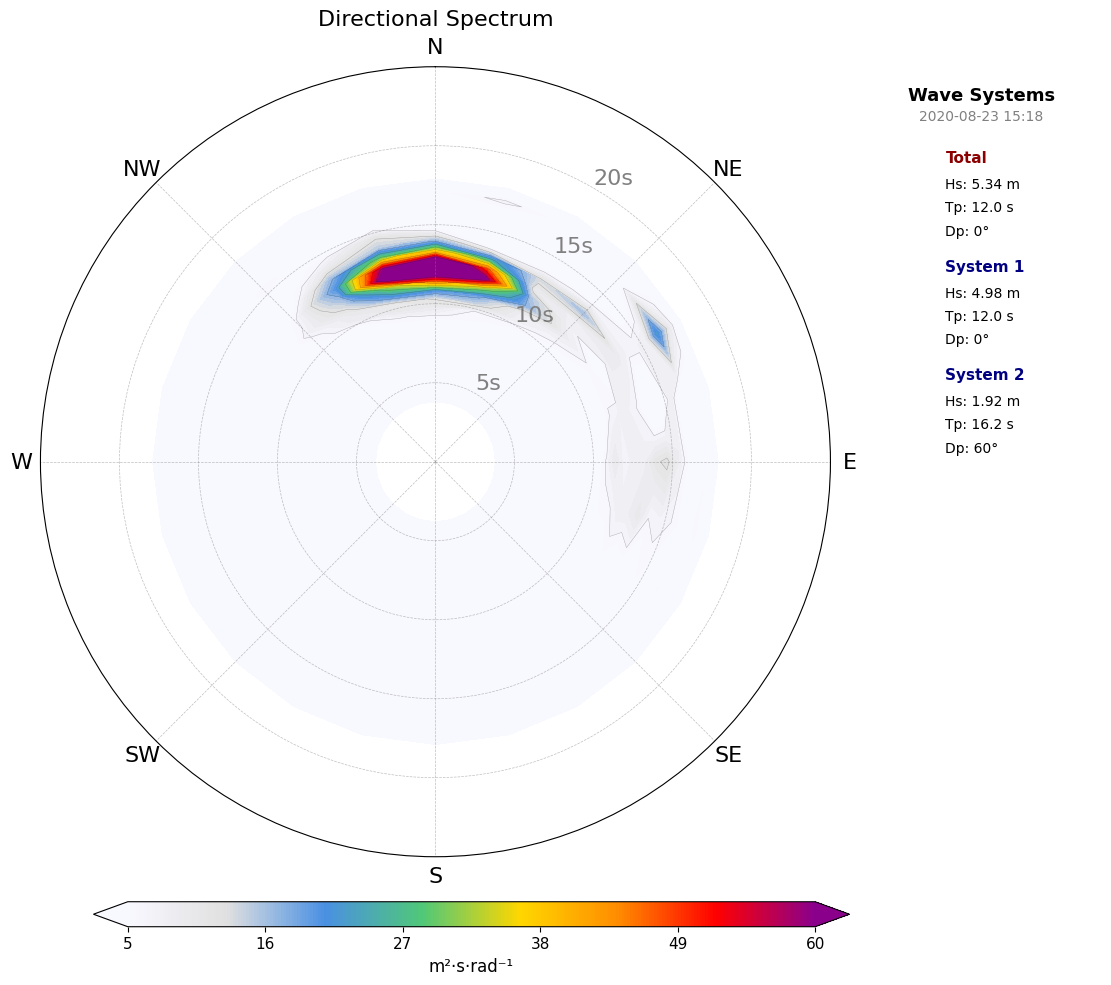

In [6]:

# ============================================================================
# PLOT: Total directional spectrum with identified wave systems
# ============================================================================

# After remove_spectral_ambiguity the energy sits at the "raw" positions in E2d
# (opposite half of the spectrum). Roll by 180° so the visual energy peak aligns
# with the corrected Dp values shown in the stats box.
E2d_plot = np.roll(E2d, E2d.shape[1] // 2, axis=1)

# Build partition list for the stats box
partitions_list = None
total_hs, total_tp, total_dp = None, None, None
if results is not None:
    min_e = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    partitions_list = [
        {'Hs': results['Hs'][i], 'Tp': results['Tp'][i], 'Dp': results['Dp'][i]}
        for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_e
    ]
    total_hs = results['total_Hs']
    total_tp = results['total_Tp']
    total_dp = results['total_Dp']

fig, ax = plot_directional_spectrum(
    E2d_plot,
    freq,
    dirs,
    selected_time=selected_time,
    hs=total_hs,
    tp=total_tp,
    dp=total_dp,
    vmin=CONFIG['plotting']['cfosat'].get('spectrum_vmin'),
    vmax=CONFIG['plotting']['cfosat'].get('spectrum_vmax'),
    partitions=partitions_list,
)

plt.show()


## 6. 1D-Spectrum


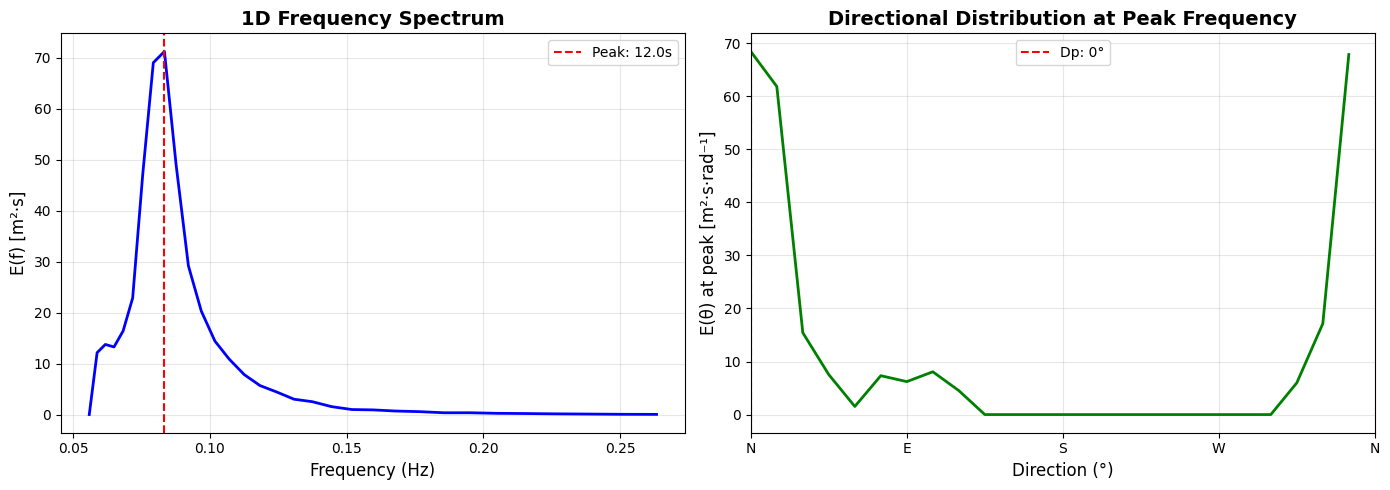

In [7]:
# Calculate 1D spectrum (direction-integrated — same regardless of roll)
spec1d, ddir = spectrum1d_from_2d(E2d, dirs_rad)

# Corrected peak direction (consistent with partition Dp and plot)
dp_corrected = (dp + 180.0) % 360.0

# Plot 1D spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Frequency spectrum
ax1.plot(freq, spec1d, 'b-', linewidth=2)
ax1.axvline(freq[i_peak], color='r', linestyle='--', label=f'Peak: {1/freq[i_peak]:.1f}s')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('E(f) [m²·s]', fontsize=12)
ax1.set_title('1D Frequency Spectrum', fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Directional distribution at peak frequency (use rolled E2d so energy is at correct direction)
ax2.plot(dirs, E2d_plot[i_peak, :], 'g-', linewidth=2)
ax2.axvline(dp_corrected, color='r', linestyle='--', label=f'Dp: {dp_corrected:.0f}°')
ax2.set_xlabel('Direction (°)', fontsize=12)
ax2.set_ylabel('E(θ) at peak [m²·s·rad⁻¹]', fontsize=12)
ax2.set_title('Directional Distribution at Peak Frequency', fontsize=14, weight='bold')
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


## 7. Save Partition Results

Save the partitioning output to CSV for downstream analysis and comparison.


In [8]:
# ============================================================================
# SAVE PARTITION RESULTS
# ============================================================================
output_dir = f'../data/partition-cfosat-{THRESHOLD_PERCENTILE}-{MERGE_FACTOR}'
os.makedirs(output_dir, exist_ok=True)

ref_id = f'box{box}_pn{posneg}'
min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']

moments  = results['moments']
m0_total = moments['total'][0]
m1_total = moments['total'][1]
m2_total = moments['total'][2]

# Corrected total Hs (sum of significant partition energies)
energy_sum = sum(
    results['energy'][i] for i in range(len(results['energy']))
    if i == 0 or results['energy'][i] > min_energy_threshold
)
total_Hs_corrected = 4 * np.sqrt(energy_sum)

data = {
    'reference_id': ref_id,
    'box':          box,
    'posneg':       posneg,
    'obs_time':     selected_time,
    'longitude':    float(lon),
    'latitude':     float(lat),
    'source_file':  os.path.basename(file_path),

    # Total spectrum (from 2D integration)
    'total_energy': energy_sum,
    'total_Hs':     total_Hs_corrected,
    'total_Tp':     results['total_Tp'],
    'total_Dp':     results['total_Dp'],
    'total_m0':     m0_total,
    'total_m1':     m1_total,
    'total_m2':     m2_total,

}

# Add partition data (up to 3 partitions)
partition_idx = 0
for i in range(1, len(results['Hs'])):
    if results['energy'][i] > min_energy_threshold:
        partition_idx += 1
        if partition_idx > 3:
            break
        data[f'P{partition_idx}_energy'] = results['energy'][i]
        data[f'P{partition_idx}_Hs']     = results['Hs'][i]
        data[f'P{partition_idx}_Tp']     = results['Tp'][i]
        data[f'P{partition_idx}_Dp']     = results['Dp'][i]
        data[f'P{partition_idx}_m0']     = moments['m0'][i]
        data[f'P{partition_idx}_m1']     = moments['m1'][i]
        data[f'P{partition_idx}_m2']     = moments['m2'][i]

# Fill remaining partitions with zeros
for p in range(partition_idx + 1, 4):
    for key in ['energy', 'Hs', 'Tp', 'Dp', 'm0', 'm1', 'm2']:
        data[f'P{p}_{key}'] = 0.0

# Save
date_str = selected_time.strftime('%Y%m%d-%H%M%S')
output_filename = f'cfosat_{ref_id}_{date_str}.csv'
output_path = os.path.join(output_dir, output_filename)

df_results = pd.DataFrame([data])
df_results.to_csv(output_path, index=False, float_format='%.6f')

print(f"Results saved to: {output_path}")
print(f"\nColumns: {list(df_results.columns)}")
print(f"\nPreview:")
df_results.T


Results saved to: ../data/partition-cfosat-95.0-0.3/cfosat_box126_pn1_20200823-151805.csv

Columns: ['reference_id', 'box', 'posneg', 'obs_time', 'longitude', 'latitude', 'source_file', 'total_energy', 'total_Hs', 'total_Tp', 'total_Dp', 'total_m0', 'total_m1', 'total_m2', 'P1_energy', 'P1_Hs', 'P1_Tp', 'P1_Dp', 'P1_m0', 'P1_m1', 'P1_m2', 'P2_energy', 'P2_Hs', 'P2_Tp', 'P2_Dp', 'P2_m0', 'P2_m1', 'P2_m2', 'P3_energy', 'P3_Hs', 'P3_Tp', 'P3_Dp', 'P3_m0', 'P3_m1', 'P3_m2']

Preview:


,0
reference_id,box126_pn1
box,126
posneg,1
obs_time,2020-08-23 15:18:05.836503
longitude,-127.620117
latitude,-40.706055
source_file,cfosat_sar.nc
total_energy,1.780527
total_Hs,5.337455
total_Tp,11.995924
